In [1]:
# after mandate + face_mask
# XGBoost

In [2]:
# Read data
import pandas as pd
import numpy as np

X_train = pd.read_csv("../train_test/after_train_X_face_mask.csv")
y_train = pd.read_csv("../train_test/after_train_y_face_mask.csv")

X_test = pd.read_csv("../train_test/after_test_X_face_mask.csv")
y_test = pd.read_csv("../train_test/after_test_y_face_mask.csv")

# Squeeze y to 1D
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [3]:
# Random upsampling of training set
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=3034)

X_train_fm_after_ros, y_train_fm_after_ros = ros.fit_resample(X_train, y_train)

In [4]:
# # Hyperparameter tuning for XGBoost using Optuna
# # The objective is to maximize ROC-AUC using 5-fold stratified cross-validation

# import optuna
# from xgboost import XGBClassifier
# from sklearn.model_selection import StratifiedKFold, cross_val_score

# def objective(trial):
#     model = XGBClassifier(
#         n_estimators=250,
#         max_depth=trial.suggest_int("max_depth", 2, 10),
#         learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1),
#         subsample=trial.suggest_float("subsample", 0.5, 1.0),
#         colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         random_state=3034,
#         eval_metric="logloss",
#         n_jobs=-1
#     )

#     cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=3034)

#     auc_scores = cross_val_score(
#         model,
#         X_train_fm_after_ros,
#         y_train_fm_after_ros,
#         cv=cv,
#         scoring="roc_auc",
#         n_jobs=-1
#     )

#     return auc_scores.mean()

# optuna.logging.set_verbosity(optuna.logging.WARNING)
# sampler = optuna.samplers.TPESampler(seed=3034)
# study = optuna.create_study(
#     direction="maximize",
#     sampler=sampler
# )
# study.optimize(objective, n_trials=200)

# print("Best params:", study.best_params)

# import json
# with open("../model/xgboost_after_fm_params.json", "w") as f:
#     json.dump(study.best_params, f)


In [5]:
# Initialize the model with the best hyperparameters found by Optuna
from xgboost import XGBClassifier
import json

with open("../model/xgboost_after_fm_params.json", "r") as f:
    best_params = json.load(f)

print("Best params:", best_params)

best_xgboost_fm_after = XGBClassifier(
    n_estimators=250,
    **best_params,
    random_state=3034,
    eval_metric="logloss",
    n_jobs=-1
)

# Model fitting
best_xgboost_fm_after.fit(X_train_fm_after_ros, y_train_fm_after_ros)

Best params: {'max_depth': 10, 'learning_rate': 0.09780887423635722, 'subsample': 0.8853139284870211, 'colsample_bytree': 0.6097535843891249}


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6097535843891249
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [6]:
# Generate predictions on the test set
y_pred = best_xgboost_fm_after.predict(X_test)
y_prob = best_xgboost_fm_after.predict_proba(X_test)[:, 1]

# Evaluate model performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", auc)

Accuracy : 0.8532934131736527
Precision: 0.8819368879216539
Recall   : 0.9150437482359582
F1-score : 0.8981853442305029
ROC-AUC  : 0.8893455436288534


In [7]:
# Estimate stable feature importance by repeatedly refitting the model
# with different random resampling

feature_names = X_train.columns
importance_list = []

for i in range(100):
    # Different seeds
    ros = RandomOverSampler(random_state=3034 + i)
    X_res, y_res = ros.fit_resample(X_train, y_train)

    # Using best model
    model = XGBClassifier(
        n_estimators=250,
        **best_params,
        random_state=3034 + i,
        eval_metric="logloss",
        n_jobs=-1
    )

    model.fit(X_res, y_res)

    importance_list.append(model.feature_importances_)

importance_array = np.array(importance_list)  

median_importance = np.median(importance_array, axis=0)
q1 = np.percentile(importance_array, 25, axis=0)
q3 = np.percentile(importance_array, 75, axis=0)
iqr = q3 - q1

importance_df = pd.DataFrame({
    "feature": feature_names,
    "median_importance": median_importance,
    "q1": q1,
    "q3": q3,
    "iqr": iqr
}).sort_values(by="median_importance", ascending=False)

# Remove features importance start with "state"
importance_df = importance_df[
    ~importance_df["feature"].str.startswith("state")
]

display_name_map = {
    "protective_behaviour_nomask_scale": "Non-mask Protective Behaviour Score",
    "week_number": "Survey Week",
    "i11_health_Very willing": "Very Willing to Self-isolate",
    "i11_health_Very unwilling": "Very Unwilling to Self-isolate",
    "i9_health_Yes": "Willing to Self-isolate if Symptomatic",
    "d1_comorbidities_Prefer not to say": "Comorbidity Not Disclosed",
    "WCRex2_No Confidence at all": "No NHS Confidence",
    "WCRex2_Don't know": "Uncertain NHS Confidence",
    "employment_status_Not working": "Not Working",
    "PHQ4_4_Prefer not to say": "Worry Control Not Disclosed"
}

importance_df["feature"] = importance_df["feature"].replace(display_name_map)

# Save data
importance_df.to_csv("../importance/xgboost_after_face_mask_importance.csv", index=False)

print(importance_df.head(10))

                                   feature  median_importance        q1  \
7      Non-mask Protective Behaviour Score           0.052158  0.048797   
6                              Survey Week           0.024868  0.023930   
26            Very Willing to Self-isolate           0.021204  0.019665   
25          Very Unwilling to Self-isolate           0.019365  0.017504   
17  Willing to Self-isolate if Symptomatic           0.012710  0.011892   
55               Comorbidity Not Disclosed           0.012359  0.011609   
33             WCRex2_No confidence at all           0.012341  0.011832   
32                Uncertain NHS Confidence           0.012304  0.011541   
18                             Not Working           0.011684  0.011126   
53             Worry Control Not Disclosed           0.011550  0.010238   

          q3       iqr  
7   0.055196  0.006398  
6   0.026129  0.002198  
26  0.022801  0.003136  
25  0.021866  0.004362  
17  0.013356  0.001464  
55  0.013722  0.002113  

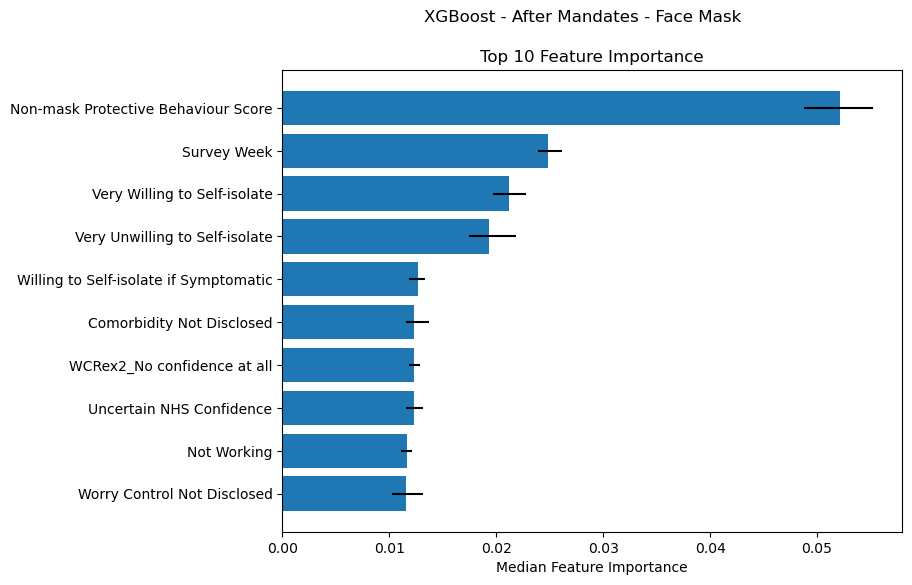

In [8]:
import matplotlib.pyplot as plt

plot_df = importance_df.head(10).copy()

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    plot_df["feature"],
    plot_df["median_importance"],
    xerr=[
        plot_df["median_importance"] - plot_df["q1"],
        plot_df["q3"] - plot_df["median_importance"]
    ]
)

ax.set_xlabel("Median Feature Importance")
ax.invert_yaxis()

ax.set_title("Top 10 Feature Importance", fontsize=12)
fig.suptitle("XGBoost - After Mandates - Face Mask", fontsize=12)

plt.show()